# Задачи к Лекции 1

Дан файл "athlete_events", который содержит информацию об олимпийских чемпионах за последние 120 лет.

**Чтение данных**

При загрузке оставляем только информацию о призерах с данными без пропусков.

In [1]:
%matplotlib inline
import zipfile
import numpy as np
import pandas as pd
import seaborn as sns

z = zipfile.ZipFile("C:/Users/ilso61/Downloads/lolol/athlete_events.zip")
df = pd.read_csv(z.open("athlete_events.csv"))
df = df.dropna(subset=['Medal', "Age", "Height", "Weight"])
df.head()

,ID,Name,Sex,Age,Height,Weight,Team,NOC,Games,Year,Season,City,Sport,Event,Medal
40,16,Juhamatti Tapio Aaltonen,M,28.0,184.0,85.0,Finland,FIN,2014 Winter,2014,Winter,Sochi,Ice Hockey,Ice Hockey Men's Ice Hockey,Bronze
41,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Individual All-Around,Bronze
42,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Team All-Around,Gold
44,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Horse Vault,Gold
48,17,Paavo Johannes Aaltonen,M,28.0,175.0,64.0,Finland,FIN,1948 Summer,1948,Summer,London,Gymnastics,Gymnastics Men's Pommelled Horse,Gold


**Получение различной информации**

In [2]:
df.shape

(30181, 15)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 30181 entries, 40 to 271103
Data columns (total 15 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   ID      30181 non-null  int64  
 1   Name    30181 non-null  object 
 2   Sex     30181 non-null  object 
 3   Age     30181 non-null  float64
 4   Height  30181 non-null  float64
 5   Weight  30181 non-null  float64
 6   Team    30181 non-null  object 
 7   NOC     30181 non-null  object 
 8   Games   30181 non-null  object 
 9   Year    30181 non-null  int64  
 10  Season  30181 non-null  object 
 11  City    30181 non-null  object 
 12  Sport   30181 non-null  object 
 13  Event   30181 non-null  object 
 14  Medal   30181 non-null  object 
dtypes: float64(3), int64(2), object(10)
memory usage: 3.7+ MB


In [4]:
df.describe()

,ID,Age,Height,Weight,Year
count,30181.000000,30181.000000,30181.000000,30181.000000,30181.000000
mean,70225.949604,25.429012,177.642358,73.753554,1988.005964
std,38839.720551,5.049684,10.924188,15.004992,22.718451
min,16.000000,13.000000,136.000000,28.000000,1896.000000
25%,37494.000000,22.000000,170.000000,63.000000,1976.000000
50%,69771.000000,25.000000,178.000000,73.000000,1992.000000
75%,104111.000000,28.000000,185.000000,83.000000,2006.000000
max,135563.000000,66.000000,223.000000,182.000000,2016.000000


**1. Сколько мужчин и женщин получили золотые, серебрянные и бронзовые медали?**

In [9]:
# Your code here
df['Medal'].value_counts()

Medal
Gold      10167
Bronze    10148
Silver     9866
Name: count, dtype: int64

**2. Какая страна получила наибольшее количество золотых медалей за всю историю олимпийских игр?**

In [12]:
# Your code here
gold_medals = (df[df['Medal'] == 'Gold'])
gold_by_country = gold_medals.groupby('NOC').size().reset_index(name='Gold_Medals')
gold_by_country.sort_values('Gold_Medals', ascending=False).iloc[0]

NOC             USA
Gold_Medals    2115
Name: 99, dtype: object

**3. Выведите распределение пола участника олимпиады от вида спорта (crosstab)**

In [13]:
# Your code here
pd.crosstab(df['Sport'], df['Sex'], margins=True, margins_name='Total')

Sex,F,M,Total
Sport,,,
Alpine Skiing,180,174,354
Archery,100,106,206
Art Competitions,0,2,2
Athletics,1239,2409,3648
Badminton,73,81,154
Baseball,0,333,333
Basketball,390,610,1000
Beach Volleyball,35,33,68
Biathlon,147,241,388


**4. Выведите средний возраст и его стандартное отклонения для женщин, учавствовавших в хоккее на льду**

In [15]:
# Your code here
women_hockey = df[(df['Sex'] == 'F') & (df['Sport'] == 'Ice Hockey')]
mean_age = women_hockey['Age'].mean()
std_age = women_hockey['Age'].std()
print(mean_age)
print(std_age)

24.42
4.360463907080283


**5. У какой страны больше всего было больше всего женщин, получивших бронзовую медаль?**

In [17]:
# Your code here
gold_medals = (df[df['Medal'] == 'Gold'])
gold_medals_F = (df[df['Sex'] == 'F'])
gold_by_country = gold_medals_F.groupby('NOC').size().reset_index(name='Gold_Medals')
gold_by_country.sort_values('Gold_Medals', ascending=False).iloc[0]

NOC             USA
Gold_Medals    1651
Name: 93, dtype: object

**6. Постройте гистограмму распределения количества медалей (бронза, серебро, золото) для первых трех стран, получивших наибольшее количество медалей**

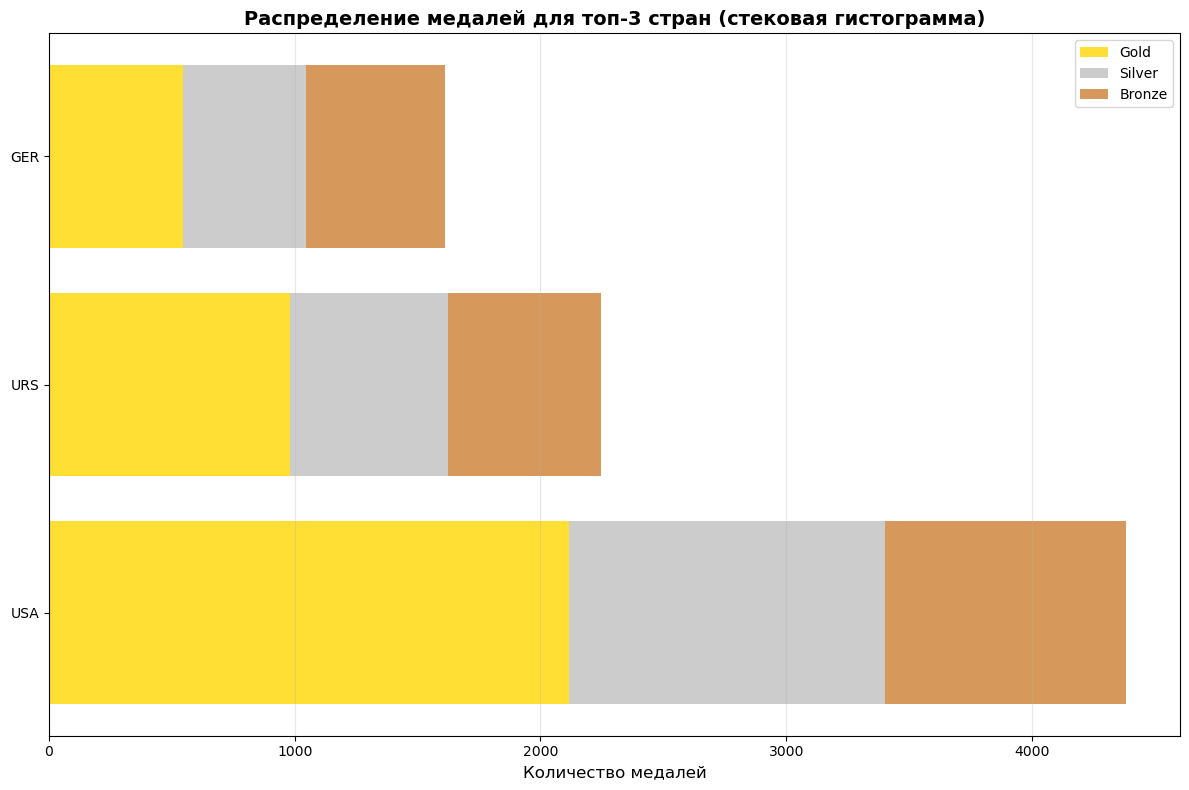

In [21]:
# Your code here
import matplotlib.pyplot as plt
top_countries = df['NOC'].value_counts().head(3).index.tolist()
medal_counts = [] #новый датафрейм с количеством медалей у каждой из трех стран
for country in top_countries:
    country_medals =df[df['NOC'] == country]['Medal'].value_counts()
    medal_counts.append({
        'Country': country,
        'Gold': country_medals.get('Gold', 0),
        'Silver': country_medals.get('Silver', 0),
        'Bronze': country_medals.get('Bronze', 0),
        'Total': country_medals.sum()
    })

medal_df = pd.DataFrame(medal_counts)

# Горизонтальная гистограмма
fig, ax = plt.subplots(figsize=(12, 8))


bottom = np.zeros(len(top_countries))
colors = ['gold', 'silver', '#cd7f32']
medal_types = ['Gold', 'Silver', 'Bronze']

for i, medal_type in enumerate(medal_types):
    values = medal_df[medal_type].values
    ax.barh(top_countries, values, left=bottom, 
            label=medal_type, color=colors[i], alpha=0.8)
    bottom += values

ax.set_xlabel('Количество медалей', fontsize=12)
ax.set_title('Распределение медалей для топ-3 стран (стековая гистограмма)', 
             fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

**7. Нарисуйте распределение веса мужчин, получивших серебрянную медаль(density или distplot)**

C:\Users\ilso61\AppData\Local\Temp\ipykernel_8028\4078988333.py:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(silver_men['Weight'], kde=True, hist=True, color='silver')


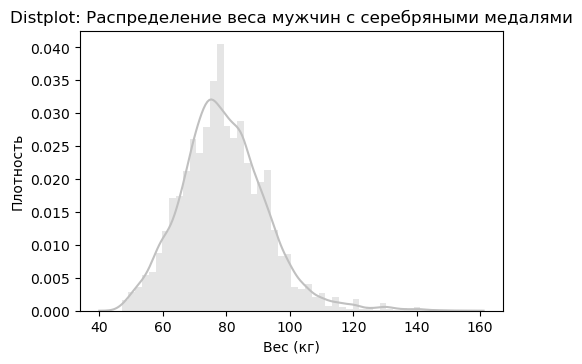

In [22]:
# Your code here
silver_men = df[(df['Sex'] == 'M') & 
                (df['Medal'] == 'Silver') & 
                (df['Weight'])]
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
sns.distplot(silver_men['Weight'], kde=True, hist=True, color='silver')
plt.title('Distplot: Распределение веса мужчин с серебряными медалями')
plt.xlabel('Вес (кг)')
plt.ylabel('Плотность')
plt.show()

**8. Постройте boxplot для возраста участника в зависимости от медали**

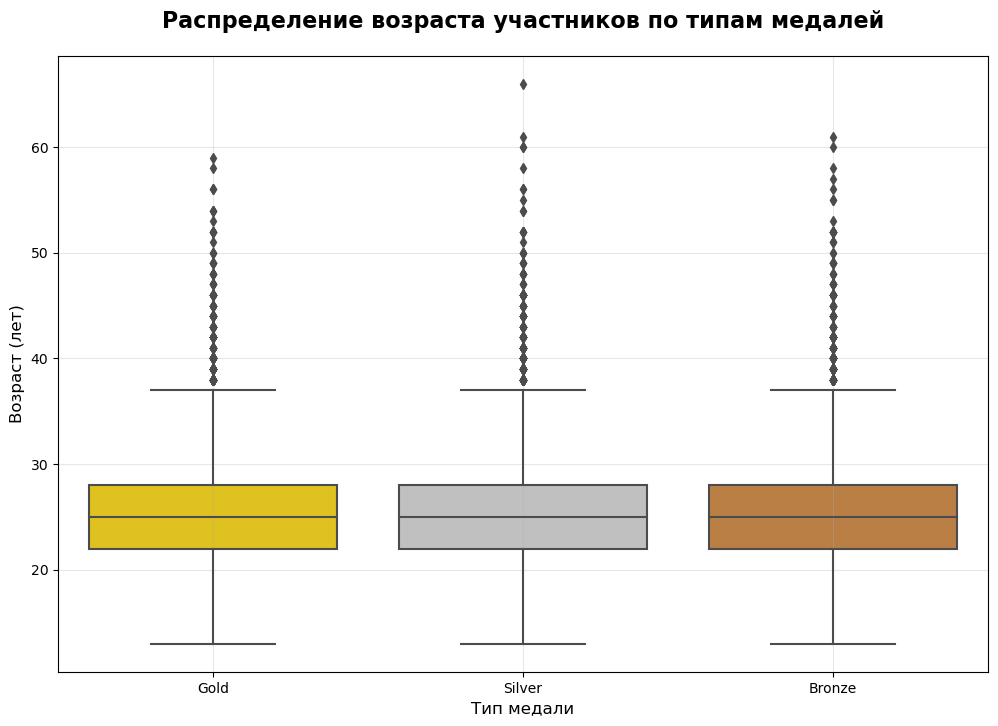

In [26]:
# Your code here
medal_winners = df[(df['Medal'].notna()) & (df['Age'].notna())]
plt.figure(figsize=(12, 8))

# Основной boxplot
sns.boxplot(data=medal_winners, x='Medal', y='Age', 
            order=['Gold', 'Silver', 'Bronze'],
            palette=['gold', 'silver', '#cd7f32'])
plt.title('Распределение возраста участников по типам медалей', 
          fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Тип медали', fontsize=12)
plt.ylabel('Возраст (лет)', fontsize=12)
plt.grid(True, alpha=0.3)


plt.show()

**9. Постройте pairplot для веса, возраста и роста участников от USA.**

C:\ProgramData\anaconda3\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)
C:\Users\ilso61\AppData\Local\Temp\ipykernel_8028\176261565.py:13: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


<Figure size 1200x1000 with 0 Axes>

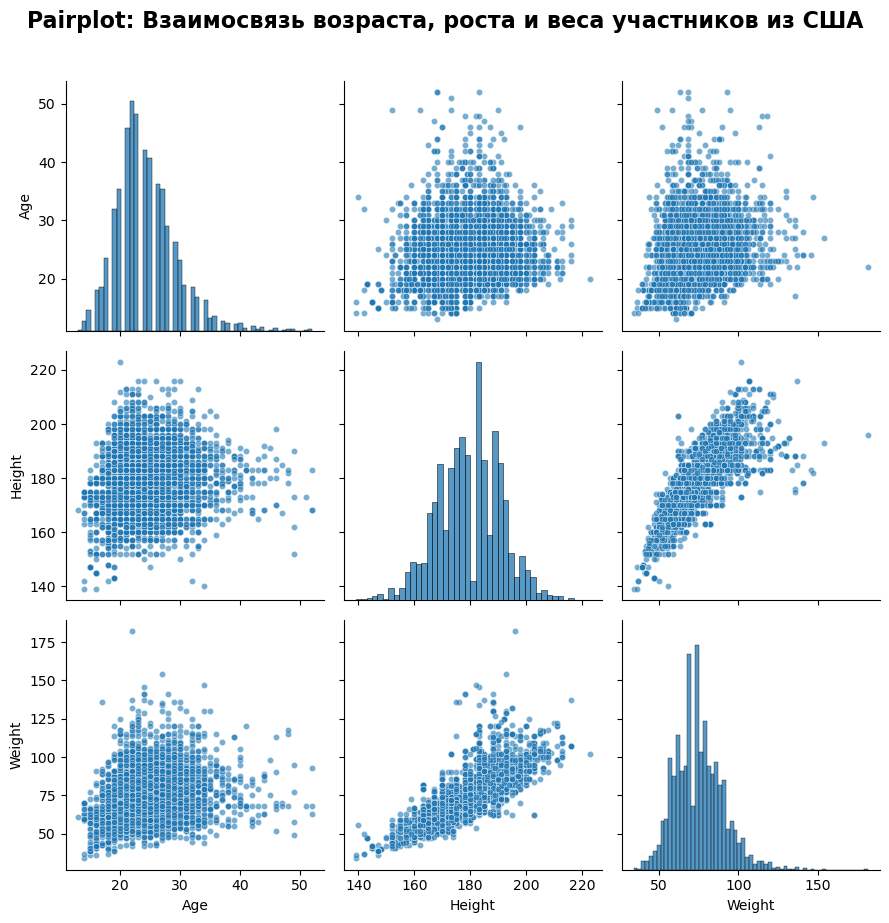

In [27]:
# Your code here
usa_athletes = df[(df['NOC'] == 'USA') & 
                  (df['Weight'].notna()) & 
                  (df['Age'].notna()) & 
                  (df['Height'].notna())]
plt.figure(figsize=(12, 10))
sns.pairplot(usa_athletes[['Age', 'Height', 'Weight']], 
             diag_kind='hist', 
             plot_kws={'alpha': 0.6, 's': 20},
             height=3)
plt.suptitle('Pairplot: Взаимосвязь возраста, роста и веса участников из США', 
             y=1.02, fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### Часть 2. NLP: BoW

In [28]:
df_au = pd.read_csv("C:/Users/ilso61/Downloads/lolol/author_ru_utf.csv")
df_au.head()

,Unnamed: 0,document,на,что,за,и,в,из,со,а,...,о,ко,над,без,при,об,через,из-за,из-под,Author
0,1,ГогольНВ_ВечераЧ1_1.txt,154,95,42,309,157,40,8,46,...,5,1,6,10,5,4,1,0,0,ГогольНВ
1,2,ГогольНВ_ВечераЧ1_2.txt,179,158,71,413,233,40,8,53,...,15,2,4,8,11,7,5,1,0,ГогольНВ
2,3,ГогольНВ_ВечераЧ1_3.txt,164,140,52,363,214,29,4,49,...,10,3,5,4,12,4,6,1,1,ГогольНВ
3,4,ГогольНВ_ВечераЧ2_1.txt,172,160,42,370,211,50,7,60,...,9,3,6,12,11,10,4,0,0,ГогольНВ
4,5,ГогольНВ_ВечераЧ2_2.txt,171,129,43,331,183,41,7,67,...,13,3,8,12,6,3,7,5,1,ГогольНВ


In [29]:
df_au.shape

(456, 30)

In [30]:
df_au.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 30 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Unnamed: 0  456 non-null    int64 
 1   document    456 non-null    object
 2   на          456 non-null    int64 
 3   что         456 non-null    int64 
 4   за          456 non-null    int64 
 5   и           456 non-null    int64 
 6   в           456 non-null    int64 
 7   из          456 non-null    int64 
 8   со          456 non-null    int64 
 9   а           456 non-null    int64 
 10  во          456 non-null    int64 
 11  для         456 non-null    int64 
 12  с           456 non-null    int64 
 13  но          456 non-null    int64 
 14  к           456 non-null    int64 
 15  по          456 non-null    int64 
 16  от          456 non-null    int64 
 17  под         456 non-null    int64 
 18  до          456 non-null    int64 
 19  про         456 non-null    int64 
 20  о         

In [31]:
df_au.describe()

,Unnamed: 0,на,что,за,и,в,из,со,а,во,...,про,о,ко,над,без,при,об,через,из-за,из-под
count,456.00000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,...,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.000000,456.00000
mean,228.50000,110.567982,148.342105,35.521930,365.462719,183.274123,26.129386,9.083333,63.245614,10.219298,...,7.065789,26.269737,3.717105,4.258772,9.206140,7.096491,6.515351,4.326754,1.826754,0.75000
std,131.78012,36.909985,56.245471,13.203711,125.051158,63.000344,12.215228,5.164723,29.965566,5.826818,...,5.271951,15.090192,3.582162,3.080411,4.954435,4.701123,4.787780,3.259581,1.727167,1.14786
min,1.00000,14.000000,36.000000,7.000000,52.000000,19.000000,2.000000,0.000000,9.000000,1.000000,...,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,114.75000,82.000000,109.000000,27.000000,282.750000,140.750000,18.000000,5.000000,42.000000,6.000000,...,3.000000,15.000000,1.000000,2.000000,6.000000,4.000000,3.000000,2.000000,1.000000,0.00000
50%,228.50000,107.000000,137.500000,34.000000,349.500000,173.000000,24.000000,8.000000,58.000000,9.000000,...,6.000000,23.000000,3.000000,4.000000,8.000000,6.000000,6.000000,4.000000,1.000000,0.00000
75%,342.25000,134.000000,176.250000,43.000000,429.500000,215.500000,32.000000,12.000000,81.000000,13.000000,...,10.000000,34.000000,5.000000,6.000000,12.000000,10.000000,9.000000,6.000000,3.000000,1.00000
max,456.00000,241.000000,433.000000,94.000000,901.000000,429.000000,84.000000,37.000000,216.000000,37.000000,...,32.000000,83.000000,29.000000,16.000000,30.000000,25.000000,26.000000,20.000000,11.000000,8.00000


**1. Какая служебная часть речи чаще всего встречается Н.В. Гоголя?**

In [37]:
# Your code here
gogol_df = df_au[(df_au['Author'] == 'ГогольНВ')]
service_pos_columns = ['на', 'что', 'за', 'и', 'в', 'из', 'со', 'а', 'во', 'для', 'с', 'но', 'к', 'по', 
                     'от', 'под', 'до', 'про', 'о', 'ко', 'над', 'без', 'при', 'об', 'через', 'из-за', 'из-под']
service_pos_sums = gogol_df[service_pos_columns].sum()
most_common_service_pos = service_pos_sums.idxmax()
most_common_count = service_pos_sums.max()
print(service_pos_sums.sort_values(ascending=False).head())

и      14427
в       8208
на      5495
что     5386
с       3771
dtype: int64


**2. Постройте гистограмму распределения предлогов "на", "с", "в" у авторов**

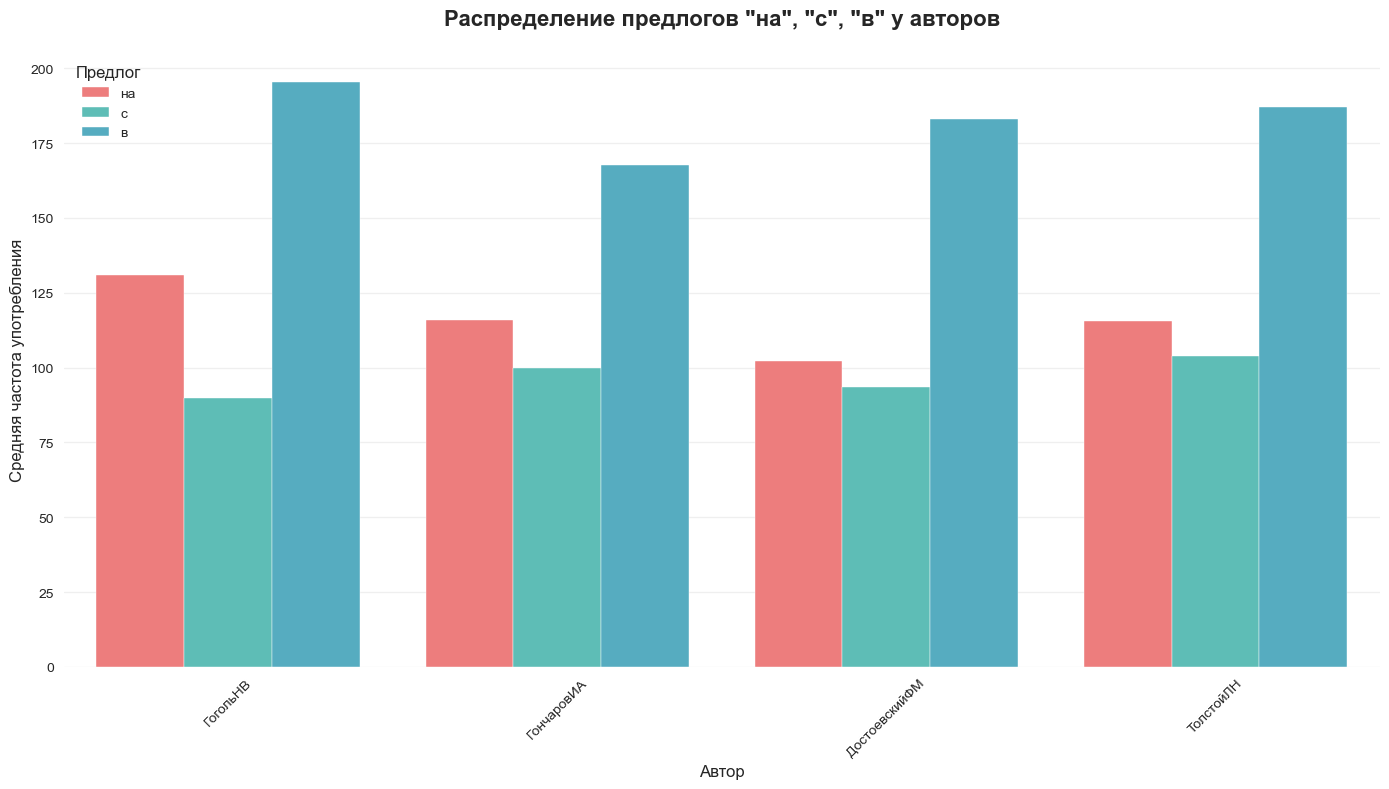

In [43]:
# Your code here
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")


# Подготовка данных для построения графиков
prepositions_data = df_au.melt(id_vars=['Author', 'document'], 
                          value_vars=['на', 'с', 'в'],
                          var_name='Предлог', 
                          value_name='Количество')

# Настройка стиля
plt.figure(figsize=(14, 8))
sns.set_style("whitegrid")

# вычисляем средние значения для каждого автора
prep_na = df_au.groupby('Author')['на'].mean()
prep_s = df_au.groupby('Author')['с'].mean()
prep_v = df_au.groupby('Author')['в'].mean()

# DataFrame для гистограммы
prep_df = pd.DataFrame({
    'Автор': prep_na.index.tolist() * 3,
    'Предлог': ['на'] * len(prep_na) + ['с'] * len(prep_s) + ['в'] * len(prep_v),
    'Средняя_частота': pd.concat([prep_na, prep_s, prep_v])
})

# Построение гистограммы
sns.barplot(data=prep_df, x='Автор', y='Средняя_частота', hue='Предлог', 
           palette=['#FF6B6B', '#4ECDC4', '#45B7D1'])

plt.title('Распределение предлогов "на", "с", "в" у авторов', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Автор', fontsize=12)
plt.ylabel('Средняя частота употребления', fontsize=12)
plt.xticks(rotation=45)
plt.legend(title='Предлог', title_fontsize=12)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

**3. Постройте boxplot для предлога "из-за" для авторов**

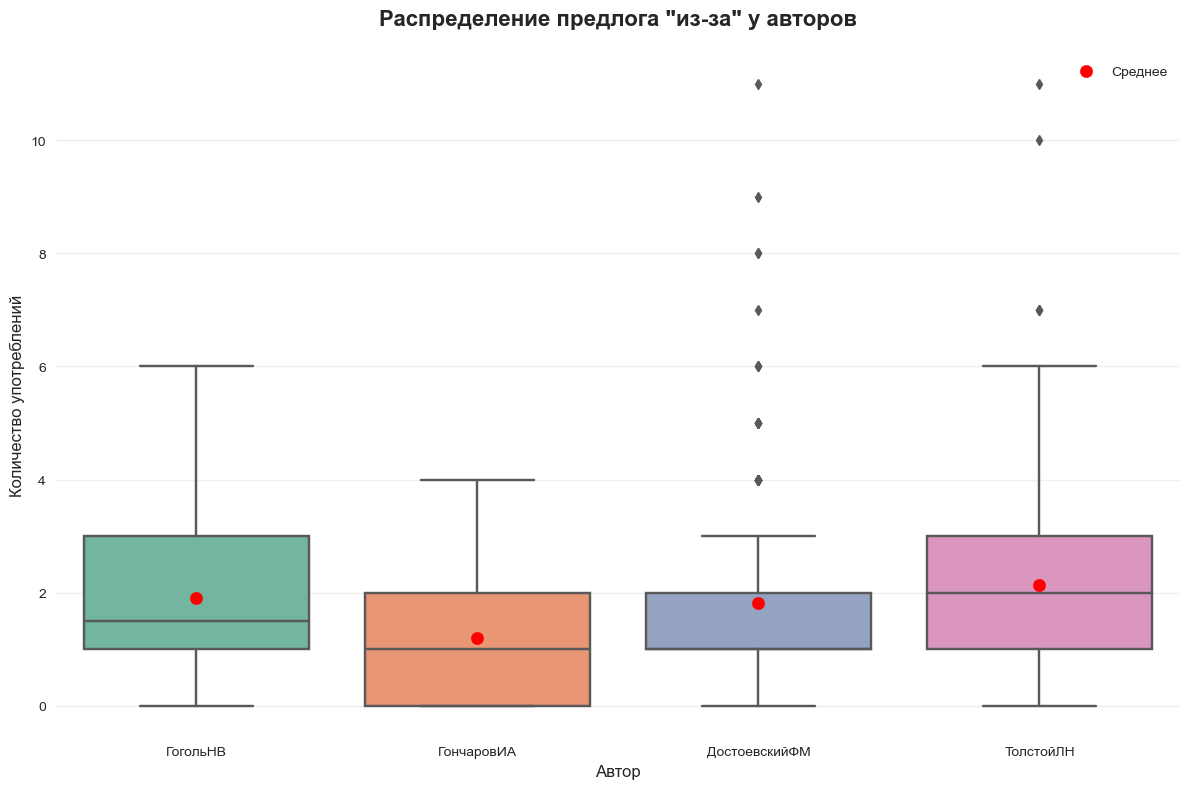

In [44]:
# Your code here
plt.figure(figsize=(12, 8))
sns.set_style("whitegrid")

# Построение boxplot для предлога "из-за"
sns.boxplot(data=df_au, x='Author', y='из-за', palette='Set2')

plt.title('Распределение предлога "из-за" у авторов', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Автор', fontsize=12)
plt.ylabel('Количество употреблений', fontsize=12)
plt.grid(axis='y', alpha=0.3)


means = df_au.groupby('Author')['из-за'].mean()
for i, author in enumerate(means.index):
    plt.scatter(i, means[author], color='red', zorder=3, s=80, label='Среднее' if i == 0 else "")

plt.legend()
plt.tight_layout()
plt.show()

**4. Создайте распределение предлога "за" по двум любым авторам**

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


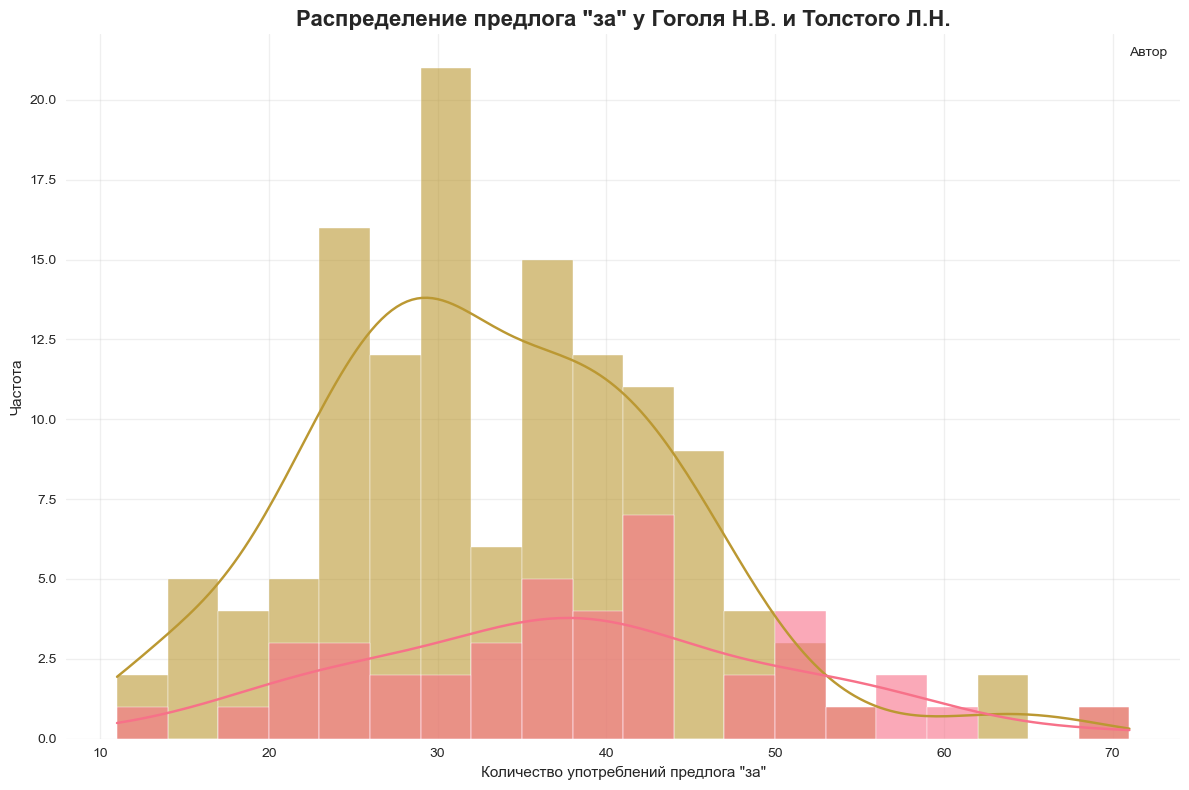

In [47]:
# Your code here

# Фильтруем данные
authors_data = df_au[df_au['Author'].isin(['ГогольНВ', 'ТолстойЛН'])]

# Основной график
plt.figure(figsize=(12, 8))

# Комбинированный график: гистограмма + KDE
sns.histplot(data=authors_data, x='за', hue='Author', bins=20, alpha=0.6, kde=True)
plt.title(f'Распределение предлога "за" у Гоголя Н.В. и Толстого Л.Н.', fontsize=16, fontweight='bold')
plt.xlabel('Количество употреблений предлога "за"')
plt.ylabel('Частота')
plt.legend(title='Автор')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()